In [1]:
!pip install pgmpy
!pip install daft


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.7 MB/s eta 0:00:00


In [ ]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import AUC
from imblearn.over_sampling import SMOTE

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os
import gc
import pdb

# Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the Excel file into a DataFrame
file_path = '/content/drive/MyDrive/longcovid.csv'
longcovid = pd.read_csv(file_path)  # Replace 'Sheet1' with the actual sheet name
#lc2=pd.read_excel(file_path, sheet_name='Follow-up at 6 months')


In [ ]:
longcovid.shape

(487, 53)

In [ ]:
# List of underlying conditions
underlying_conditions = ['diabetes', 'hypertension', 'asthma',
                         'cancer', 'tb', 'cancer', 'anxiety',
                        'obesity', 'other_medical']
# Creating the 'under_cond' column
longcovid['under_cond'] = longcovid[underlying_conditions].any(axis=1).astype(int)

In [ ]:
# Replacing values of 2 with 1 in the 'longcovid_six' column
# 2 objects of 2(yes - a lot)
longcovid['longcovid_six'] = longcovid['longcovid_six'].replace(2, 1)

In [ ]:
# Replacing values of 2 with 1 in the 'longcovid_six' column
# 1 objects of 3 encoded to 2 (severe - moderate)
longcovid['vaccine_effect'] = longcovid['vaccine_effect'].replace(3, 2)

In [ ]:
 #Replacing values of 2 with 1 in the 'longcovid_six' column
 # limited activity grouped together on a lot and a little 10
longcovid['lc_activitylimit_four'] = longcovid['lc_activitylimit_four'].replace(2, 1)

In [ ]:
 #Replacing values of 2 with 1 in the 'longcovid_six' column
 # yes (grouped together on severe and mild) 11
longcovid['longcovid_four'] = longcovid['longcovid_four'].replace(2, 1)

In [ ]:
longcovid['longcovid_six'].unique()

array([0, 1])

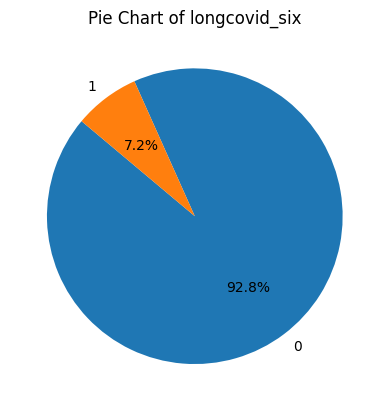

In [ ]:
category_counts = longcovid['longcovid_six'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of longcovid_six')
plt.show()

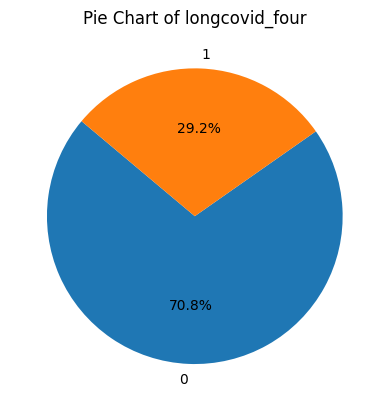

In [ ]:
category_counts = longcovid['longcovid_four'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of longcovid_four')
plt.show()

In [ ]:
covidpgm = PGM(shape=[15,15])
# Background
covidpgm.add_node(daft.Node('Age_group','Age Group',2,1, scale=1.5))
covidpgm.add_node(daft.Node('sex','Gender',2,2, scale=1.5))
covidpgm.add_node(daft.Node('education','Education',2,3, scale=1.5))
covidpgm.add_node(daft.Node('smoking','Smoking',2,4, scale=1.5))
covidpgm.add_node(daft.Node('alcohol','Alcohol',2,7, scale=1.5))
covidpgm.add_node(daft.Node('drugs','Drugs',2,8, scale=1.5))
covidpgm.add_node(daft.Node('occupation','Occupation',2,5, scale=1.5))
covidpgm.add_node(daft.Node('occupation_covid','Occupation\nCovid',2,6, scale=1.5))
covidpgm.add_node(daft.Node('past_history_covid','History\nCOVID',2,10, scale=1.5))
covidpgm.add_node(daft.Node('date_diff_four_4_classes','days since\nCOVID',2,9, scale=1.5))

# Underlying Condition
covidpgm.add_node(daft.Node('under_cond','Under\nCond',2,12, scale=1.5))
covidpgm.add_node(daft.Node('hypertension','Hyper\ntension',1,12, scale=1.5))
covidpgm.add_node(daft.Node('anxiety','Anxiety',1,13, scale=1.5))
covidpgm.add_node(daft.Node('asthma','Asthma',1,14, scale=1.5))
covidpgm.add_node(daft.Node('cancer','Cancer',2,14, scale=1.5))
covidpgm.add_node(daft.Node('diabetes','Diabetes',3,14, scale=1.5))
covidpgm.add_node(daft.Node('other_medical','Other\nCond',3,13, scale=1.5))
covidpgm.add_node(daft.Node('obesity','Obesity',3,12, scale=1.5))
covidpgm.add_node(daft.Node('tb','TB',2,11, scale=1.5))

# Vaccines
covidpgm.add_node(daft.Node('vaccine_dose','Vaccine\nDose',7,6, scale=1.5))
covidpgm.add_node(daft.Node('vaccine_type','Vaccine\nType',7,5, scale=1.5))
covidpgm.add_node(daft.Node('vaccine_effect','Vaccine\nEffects',8,7, scale=1.5))

# LC Symptoms
covidpgm.add_node(daft.Node('lc_fatigue_four','LC Fatig',10.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_cough_four','LC Cough',4.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_headache_four','LC Headache',5,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_breathing_four','LC Diff\nBreathing',5.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_taste_four','LC Loss\nTaste',6,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_smell_four','LC Loss\nSmell',6.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_brainfog_four','LC Fog\nBrain',7,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_chestpain_four','LC Pain\nChest',7.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_palpitation_four','LC Palpit',8,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_anxiety_four','LC Anxie',8.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_fever_four','LC Fever',9,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_other_four','LC Other',9.5,11, scale=1.5))

# Covid Symptoms
covidpgm.add_node(daft.Node('covid_severity','COVID\nSeverity',9.5,1, scale=1.5))
covidpgm.add_node(daft.Node('covid_care','COVID\nCare',8,1, scale=1.5))

covidpgm.add_node(daft.Node('Headache','Headache',12,6.5, scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',11,6, scale=1.5))
covidpgm.add_node(daft.Node('Fever','Fever',12,5.5, scale=1.5))
covidpgm.add_node(daft.Node('Ageusia','Ageusia',11,5, scale=1.5))
covidpgm.add_node(daft.Node('Anosmia','Anosmia',12,4.5, scale=1.5))
covidpgm.add_node(daft.Node('SoreThroat','Sore\nThroat',11,4, scale=1.5))
covidpgm.add_node(daft.Node('DigestiveIssues','Digestv\nIssue',12,3.5, scale=1.5))
covidpgm.add_node(daft.Node('Cold','Cold',11,3, scale=1.5))
covidpgm.add_node(daft.Node('OtherSymptoms','Other\nSymp',12,2.5, scale=1.5))
covidpgm.add_node(daft.Node('Bodyache','Body\nAche',11,2, scale=1.5))
covidpgm.add_node(daft.Node('BreathingDifficulty','Breathe\nDiff',12,1.5, scale=1.5))
covidpgm.add_node(daft.Node('NasalIssues','Nasal\nIssues',11,1, scale=1.5))
covidpgm.add_node(daft.Node('Fatigue','Fatig',12,7.5, scale=1.5))
covidpgm.add_node(daft.Node('ChestPain','Chest\nPain',11,7, scale=1.5))


# LONG COVID
covidpgm.add_node(daft.Node('longcovid_four','LC 4\nWeeks',5,2, scale=1.5))
covidpgm.add_node(daft.Node('longcovid_six','LC 6\nMonths',6,7, scale=1.5))
covidpgm.add_node(daft.Node('lc_activitylimit_four','LC 4\nAct Limit',5,4.5, scale=1.5))
covidpgm.add_node(daft.Node('lc_consultation_four','LC 4\nConsult',6,4.5, scale=1.5))

In [ ]:
# Background
covidpgm.add_edge('Age_group','longcovid_six')
covidpgm.add_edge('sex','longcovid_six')
covidpgm.add_edge('education','longcovid_six')
covidpgm.add_edge('smoking','longcovid_six')
covidpgm.add_edge('alcohol','longcovid_six')
covidpgm.add_edge('drugs','longcovid_six')
covidpgm.add_edge('occupation','longcovid_six')
covidpgm.add_edge('occupation_covid','longcovid_six')
covidpgm.add_edge('past_history_covid','longcovid_six')
covidpgm.add_edge('date_diff_four_4_classes','longcovid_six')

# Underlying Condition
covidpgm.add_edge('under_cond','longcovid_six')
covidpgm.add_edge('hypertension','under_cond')
covidpgm.add_edge('anxiety','under_cond')
covidpgm.add_edge('asthma','under_cond')
covidpgm.add_edge('cancer','under_cond')
covidpgm.add_edge('diabetes','under_cond')
covidpgm.add_edge('other_medical','under_cond')
covidpgm.add_edge('obesity','under_cond')
covidpgm.add_edge('tb','under_cond')


# Vaccines
#highest dose, mix or covi or covax, effect
#dose > type > lc
#dose > effect > lc
#type > effect
#dose > lc ??
covidpgm.add_edge('vaccine_dose','vaccine_type')
covidpgm.add_edge('vaccine_type','longcovid_six')
covidpgm.add_edge('vaccine_type','vaccine_effect')
covidpgm.add_edge('vaccine_effect','longcovid_six')

# LC Symptoms
covidpgm.add_edge('lc_fatigue_four','longcovid_six')
covidpgm.add_edge('lc_cough_four','longcovid_six')
covidpgm.add_edge('lc_headache_four','longcovid_six')
covidpgm.add_edge('lc_breathing_four','longcovid_six')
covidpgm.add_edge('lc_taste_four','longcovid_six')
covidpgm.add_edge('lc_smell_four','longcovid_six')
covidpgm.add_edge('lc_brainfog_four','longcovid_six')
covidpgm.add_edge('lc_chestpain_four','longcovid_six')
covidpgm.add_edge('lc_palpitation_four','longcovid_six')
covidpgm.add_edge('lc_anxiety_four','longcovid_six')
covidpgm.add_edge('lc_fever_four','longcovid_six')
covidpgm.add_edge('lc_other_four','longcovid_six')

# Covid Symptoms
covidpgm.add_edge('covid_severity','longcovid_four')
covidpgm.add_edge('covid_care','longcovid_four')
covidpgm.add_edge('Headache','longcovid_four')
covidpgm.add_edge('Cough','longcovid_four')
covidpgm.add_edge('Fever','longcovid_four')
covidpgm.add_edge('Ageusia','longcovid_four')
covidpgm.add_edge('Anosmia','longcovid_four')
covidpgm.add_edge('SoreThroat','longcovid_four')
covidpgm.add_edge('DigestiveIssues','longcovid_four')
covidpgm.add_edge('Cold','longcovid_four')
covidpgm.add_edge('OtherSymptoms','longcovid_four')
covidpgm.add_edge('Bodyache','longcovid_four')
covidpgm.add_edge('BreathingDifficulty','longcovid_four')
covidpgm.add_edge('NasalIssues','longcovid_four')
covidpgm.add_edge('ChestPain','longcovid_four')
covidpgm.add_edge('Fatigue','longcovid_four')



# LONG COVID
#4 > 6
#everything > 6
#covid symp > 6 months
#covid symp > 4weeks

covidpgm.add_edge('lc_activitylimit_four','longcovid_four')
covidpgm.add_edge('lc_activitylimit_four','longcovid_six')
covidpgm.add_edge('lc_consultation_four','longcovid_four')
covidpgm.add_edge('lc_consultation_four','longcovid_six')

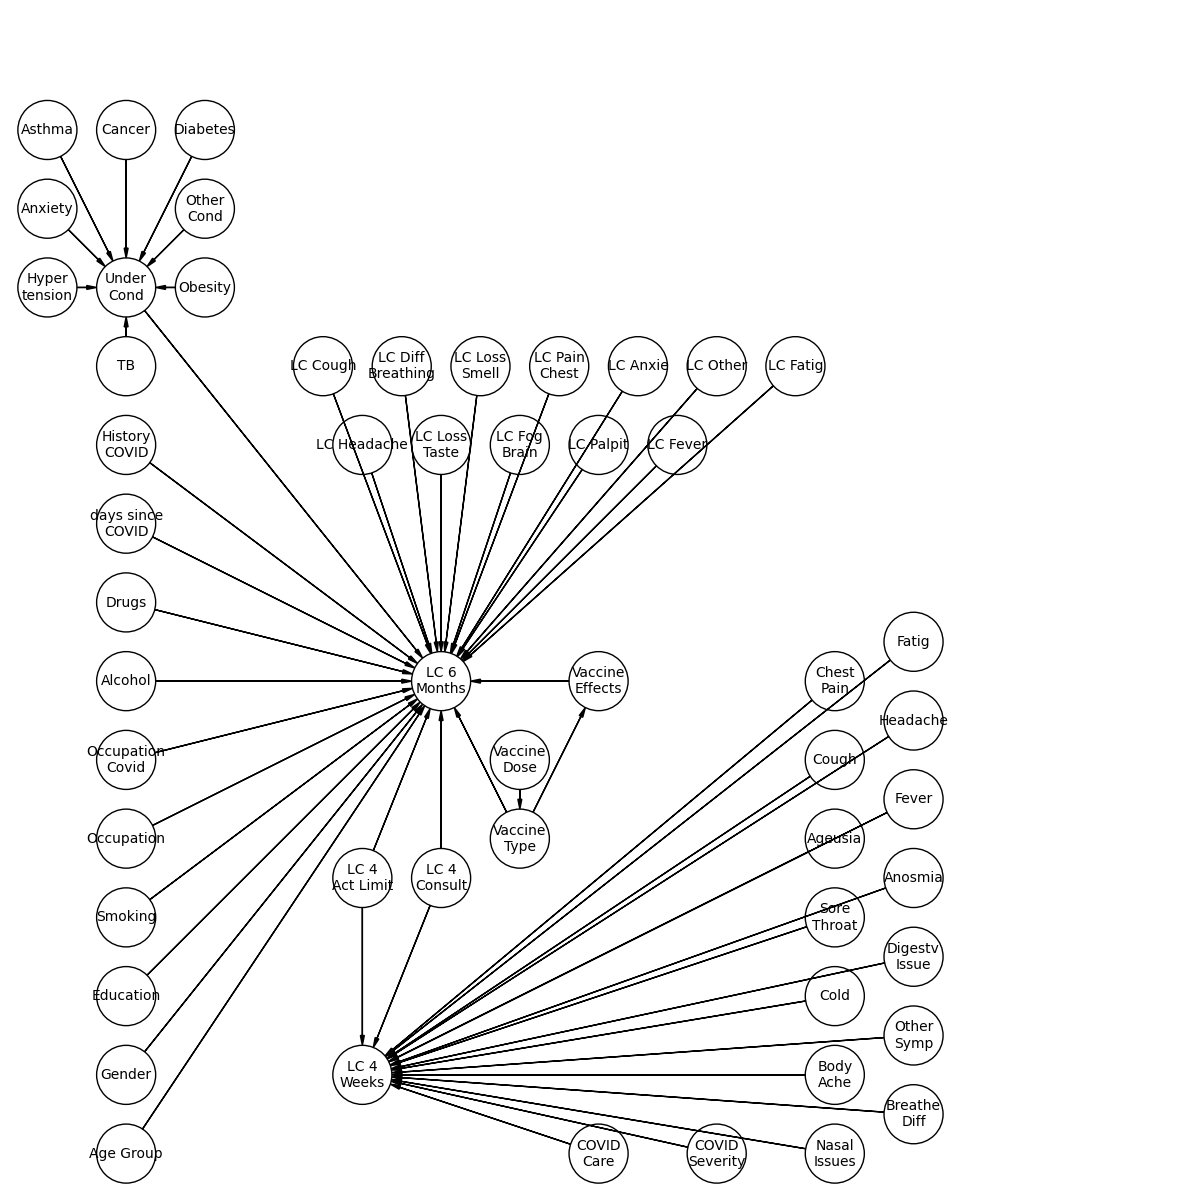

In [ ]:
covidpgm.render()
plt.show()

In [ ]:
# # Create Stratified 5-fold splitter
# # Assuming you have a target column for stratification, e.g., 'target_column'
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# for fold, (train_idx, _) in enumerate(skf.split(longcovid1, longcovid1['longcovid_six'])):
#     # We only use the train index to get each chunk since we're not actually doing cross-validation here
#     chunk = longcovid1.iloc[train_idx]
#     chunk.to_csv(f"longcovid1_part{fold + 1}.csv", index=False)


In [ ]:
bn_structure = [
    ('Age_group', 'longcovid_six'),
    ('sex', 'longcovid_six'),
    #('education', 'longcovid_six'),
    #('smoking', 'longcovid_six'),
    ('alcohol', 'longcovid_six'),
    #('drugs', 'longcovid_six'),
    ('occupation', 'longcovid_six'),
    ('occupation_covid', 'longcovid_six'),
    ('past_history_covid', 'longcovid_six'),
    #('date_diff_four_4_classes', 'longcovid_six'),

    ('hypertension', 'under_cond'),
    ('anxiety', 'under_cond'),
    ('asthma', 'under_cond'),
    ('cancer', 'under_cond'),
    ('diabetes', 'under_cond'),
    ('other_medical', 'under_cond'),
    ('obesity', 'under_cond'),
    #('tb', 'under_cond'),
    ('under_cond', 'longcovid_six'),

    ('vaccine_dose', 'vaccine_type'),
    ('vaccine_type', 'longcovid_six'),
    ('vaccine_type', 'vaccine_effect'),
    ('vaccine_effect', 'longcovid_six'),

    ('lc_fatigue_four', 'longcovid_six'),
    ('lc_cough_four', 'longcovid_six'),
    ('lc_headache_four', 'longcovid_six'),
    ('lc_breathing_four', 'longcovid_six'),
    ('lc_taste_four', 'longcovid_six'),
    ('lc_smell_four', 'longcovid_six'),
    #('lc_brainfog_four', 'longcovid_six'),
    ('lc_chestpain_four', 'longcovid_six'),
    ('lc_palpitation_four', 'longcovid_six'),
    ('lc_anxiety_four', 'longcovid_six'),
    #('lc_fever_four', 'longcovid_six'),
    ('lc_other_four', 'longcovid_six'),

    ('covid_severity', 'longcovid_four'),
    ('covid_care', 'longcovid_four'),
    #('Headache', 'longcovid_four'),
    ('Cough', 'longcovid_four'),
    ('Fever', 'longcovid_four'),
    ('Ageusia', 'longcovid_four'),
    ('Anosmia', 'longcovid_four'),
    ('SoreThroat', 'longcovid_four'),
    ('DigestiveIssues', 'longcovid_four'),
    ('Cold', 'longcovid_four'),
    ('OtherSymptoms', 'longcovid_four'),
    ('Bodyache', 'longcovid_four'),
    ('BreathingDifficulty', 'longcovid_four'),
    ('NasalIssues', 'longcovid_four'),
    ('Fatigue', 'longcovid_four'),
    #('ChestPain', 'longcovid_four'),

    ('lc_activitylimit_four', 'longcovid_four'),
    ('lc_activitylimit_four', 'longcovid_six'),
    ('lc_consultation_four', 'longcovid_four'),
    ('lc_consultation_four', 'longcovid_six')
]

In [ ]:
bnmodel1=BayesianNetwork(bn_structure)

In [ ]:
longcovid1=longcovid.loc[:, ['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'cancer','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four', 'lc_fatigue_four', 'lc_cough_four', 'lc_breathing_four', 'lc_chestpain_four','lc_headache_four',
                              'lc_taste_four','lc_smell_four','other_medical','Cold','DigestiveIssues','hypertension','anxiety','past_history_covid',
                              'lc_palpitation_four', 'lc_anxiety_four', 'lc_other_four', 'lc_activitylimit_four', 'lc_consultation_four', 'longcovid_six', 'NasalIssues','Cough',
                              'Fever', 'Bodyache', 'BreathingDifficulty', 'Ageusia', 'Anosmia', 'SoreThroat', 'Fatigue', 'OtherSymptoms', 'vaccine_dose',
                              'vaccine_effect','vaccine_type', 'Age_group', 'obesity', 'under_cond']]

In [ ]:
# Get the variable names from the Bayesian network model
variable_names_in_model = set(bnmodel1.nodes)

# Get the column names from your training data
column_names_in_data = set(longcovid1.columns)

# Identify missing columns (in the model but not in the data)
missing_columns = variable_names_in_model - column_names_in_data

# Identify excessive columns (in the data but not in the model)
excessive_columns = column_names_in_data - variable_names_in_model

# Print the results
print("Missing Columns (in the model but not in the data):", missing_columns)
print("Excessive Columns (in the data but not in the model):", excessive_columns)

Missing Columns (in the model but not in the data): set()
Excessive Columns (in the data but not in the model): set()


In [ ]:

# Combine the columns for stratification
 #Combine the columns for stratification
longcovid1['stratify_col'] = (longcovid1['vaccine_effect'].astype(str) + "_" +
                              longcovid1['longcovid_six'].astype(str))

# Perform stratified sampling based on the combined column
training_data, testing_data = train_test_split(longcovid1, test_size=0.35, random_state=42,
stratify=longcovid1['stratify_col']
                                               )

# Drop the combined column after splitting
training_data = training_data.drop(columns=['stratify_col'])
testing_data = testing_data.drop(columns=['stratify_col'])



In [ ]:


Hypercpd = TabularCPD(variable='hypertension',
                       variable_card=2,
                       values=[[0.23], [.77]]) #AIHW 34%
Diabcpd = TabularCPD(variable='diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

cancercpd = TabularCPD(variable='cancer',
                       variable_card=2,
                       values=[[.43], [.57]]) #union from AIHW 19.6%
age_group_states = [1,2,3,4]
Agecpd = TabularCPD(variable='Age_group',
                       variable_card=4,
                       values=[[0.305], [0.282], [0.242], [0.171]], state_names={'Age_group':age_group_states})




sexcpd = TabularCPD(variable='sex',
                       variable_card=2,
                       values=[[.5021], [.4979]])

Coldcpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.137], [.863]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]]) #15% on winters


BDcpd = TabularCPD(variable='BreathingDifficulty',
                       variable_card=2,
                       values=[[.075], [.925]]) #
Headachecpd = TabularCPD(variable='Headache',
                       variable_card=2,
                       values=[[.15], [.85]])
Anosmiacpd = TabularCPD(variable='Anosmia',
                       variable_card=2,
                       values=[[.03], [.97]])
Ageusiacpd = TabularCPD(variable='Ageusia',
                       variable_card=2,
                       values=[[.02], [.98]])

obescpd = TabularCPD(variable='obesity',
                       variable_card=2,
                       values=[[.687], [.313]])


bnmodel1.add_cpds(Hypercpd,Diabcpd,Asthmacpd,cancercpd,sexcpd,sexcpd,Coldcpd ,Coughcpd,BDcpd,Anosmiacpd,Ageusiacpd,obescpd,Agecpd)

In [ ]:
longcovid2=longcovid1.loc[:, [ 'occupation_covid', 'alcohol','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four', 'lc_fatigue_four', 'lc_cough_four', 'lc_breathing_four', 'lc_chestpain_four','lc_headache_four',
                              'lc_taste_four','lc_smell_four','other_medical','DigestiveIssues','anxiety','past_history_covid',
                              'lc_palpitation_four', 'lc_anxiety_four', 'lc_other_four', 'lc_activitylimit_four', 'lc_consultation_four', 'longcovid_six', 'NasalIssues',
                              'Fever', 'Bodyache', 'SoreThroat', 'Fatigue', 'OtherSymptoms', 'vaccine_dose','vaccine_type', 'under_cond','vaccine_effect']]

In [ ]:
# Bayesian Estimation on the Training Data
estimator = BayesianEstimator(bnmodel1, training_data)
columns = longcovid2.columns.tolist()
for column in columns:
    cpd = estimator.estimate_cpd(column)
    bnmodel1.add_cpds(cpd)

In [ ]:
# 1. Gather States from CPDs
cpd_states = {cpd.variable: set(cpd.state_names[cpd.variable]) for cpd in bnmodel1.get_cpds()}

# 2. Gather States from Data
data_states_train = {column: set(training_data[column].unique()) for column in training_data.columns}
data_states_test = {column: set(testing_data[column].unique()) for column in testing_data.columns}

# 3. Compare
mismatches_train = {column: data_states_train[column] - cpd_states.get(column, set()) for column in data_states_train}
mismatches_test = {column: data_states_test[column] - cpd_states.get(column, set()) for column in data_states_test}

print("Mismatches in Training Data:", mismatches_train)
print("Mismatches in Testing Data:", mismatches_test)

Mismatches in Training Data: {'sex': set(), 'occupation_covid': set(), 'alcohol': set(), 'diabetes': set(), 'asthma': set(), 'cancer': set(), 'occupation': set(), 'covid_severity': set(), 'covid_care': set(), 'longcovid_four': set(), 'lc_fatigue_four': set(), 'lc_cough_four': set(), 'lc_breathing_four': set(), 'lc_chestpain_four': set(), 'lc_headache_four': set(), 'lc_taste_four': set(), 'lc_smell_four': set(), 'other_medical': set(), 'Cold': set(), 'DigestiveIssues': set(), 'hypertension': set(), 'anxiety': set(), 'past_history_covid': set(), 'lc_palpitation_four': set(), 'lc_anxiety_four': set(), 'lc_other_four': set(), 'lc_activitylimit_four': set(), 'lc_consultation_four': set(), 'longcovid_six': set(), 'NasalIssues': set(), 'Cough': set(), 'Fever': set(), 'Bodyache': set(), 'BreathingDifficulty': set(), 'Ageusia': set(), 'Anosmia': set(), 'SoreThroat': set(), 'Fatigue': set(), 'OtherSymptoms': set(), 'vaccine_dose': set(), 'vaccine_effect': set(), 'vaccine_type': set(), 'Age_group

In [ ]:
# longcovid_six_cpd = bnmodel1.get_cpds('longcovid_six')

# # Access the values of the CPD
# cpd_values = longcovid_six_cpd.values

# # Print the CPD values
# print(cpd_values)


In [ ]:
# # Extract CPDs from bnmodel1
# cpds = bnmodel1.get_cpds()

# # Convert each CPD to a string and collect them in a list
# cpd_strings = [str(cpd) for cpd in cpds]

# # Join the CPD strings with a separator and write to a file
# filename = "bnmodel1_cpds.txt"
# with open(filename, "w") as file:
#     file.write("\n\n=========================\n\n".join(cpd_strings))

In [ ]:
X_train = training_data.drop(columns=['longcovid_six'])
y_train = training_data['longcovid_six']

columns_with_2 = X_train.columns[X_train.isin([1]).any()].tolist()
print(columns_with_2)

columns_with_few_2s = {col: X_train[col].value_counts().get(2, 0) for col in X_train.columns}
columns_with_few_2s = {col: count for col, count in columns_with_few_2s.items() if count > 0 and count < 5}
print(columns_with_few_2s)


['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'cancer', 'occupation', 'covid_severity', 'covid_care', 'longcovid_four', 'lc_fatigue_four', 'lc_cough_four', 'lc_breathing_four', 'lc_chestpain_four', 'lc_headache_four', 'lc_taste_four', 'lc_smell_four', 'other_medical', 'Cold', 'DigestiveIssues', 'hypertension', 'anxiety', 'past_history_covid', 'lc_palpitation_four', 'lc_anxiety_four', 'lc_other_four', 'lc_activitylimit_four', 'lc_consultation_four', 'NasalIssues', 'Cough', 'Fever', 'Bodyache', 'BreathingDifficulty', 'Ageusia', 'Anosmia', 'SoreThroat', 'Fatigue', 'OtherSymptoms', 'vaccine_dose', 'vaccine_effect', 'vaccine_type', 'Age_group', 'obesity', 'under_cond']
{'covid_severity': 2, 'vaccine_effect': 2}


In [ ]:
#Split testing data into features and target
X_test = testing_data.drop(columns=['longcovid_six'])
y_test = testing_data['longcovid_six']

columns_with_2 = X_test.columns[X_test.isin([1]).any()].tolist()
print(columns_with_2)

columns_with_few_2s = {col: X_test[col].value_counts().get(2, 0) for col in X_test.columns}
columns_with_few_2s = {col: count for col, count in columns_with_few_2s.items() if count > 0 and count < 5}
print(columns_with_few_2s)


['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'cancer', 'occupation', 'covid_severity', 'covid_care', 'longcovid_four', 'lc_fatigue_four', 'lc_cough_four', 'lc_breathing_four', 'lc_chestpain_four', 'lc_taste_four', 'lc_smell_four', 'other_medical', 'Cold', 'DigestiveIssues', 'hypertension', 'anxiety', 'past_history_covid', 'lc_palpitation_four', 'lc_anxiety_four', 'lc_other_four', 'lc_activitylimit_four', 'lc_consultation_four', 'NasalIssues', 'Cough', 'Fever', 'Bodyache', 'BreathingDifficulty', 'Ageusia', 'Anosmia', 'SoreThroat', 'Fatigue', 'OtherSymptoms', 'vaccine_dose', 'vaccine_effect', 'vaccine_type', 'Age_group', 'obesity', 'under_cond']
{'covid_severity': 2, 'vaccine_effect': 1}


In [ ]:
X_test.shape

(171, 44)

In [ ]:
# # Select a row from X_test where vaccine_effect is 1
# selected_row = X_test[X_test['vaccine_effect'] == 1].iloc[0]

# # Create the evidence dictionary for the selected row
# evidence = {k: int(v) for k, v in selected_row.to_dict().items() if k != 'longcovid_six'}

# # Output the evidence to inspect
# evidence

In [ ]:
# # Select a row from X_test where vaccine_effect is 1
# #pdb.set_trace()
# selected_row = X_test[X_test['vaccine_effect'] == 0].iloc[0]

# # Create the evidence dictionary for the selected row
# evidence = {k: int(v) for k, v in selected_row.to_dict().items() if k != 'longcovid_six'}

# # Query the Bayesian network with the evidence
# result = infer.query(['longcovid_six'], evidence=evidence)
# result

In [ ]:
# # List of columns that need to be converted to strings
# columns_to_convert = testing_data.columns.tolist()  # This converts all columns; you can specify a subset if needed

# for col in columns_to_convert:
#     testing_data[col] = testing_data[col].astype(str)

In [ ]:
# Predictions using the Bayesian network
from scipy import interpolate


infer = VariableElimination(bnmodel1)
p = 0.8

# Modified predictions code with string conversion for evidence values
predictions = [
    infer.query(['longcovid_six'],
                evidence={k: int(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}).values[1]
    for _, row in testing_data.iterrows()
]


newpred = [1 if pred >= p else 0 for pred in predictions]
accuracy = accuracy_score(y_test, newpred)
precision = precision_score(y_test, newpred)
accuracy = accuracy_score(y_test, newpred)
precision = precision_score(y_test, newpred)
recall = recall_score(y_test, newpred)
f1 = f1_score(y_test, newpred)
tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
specificity = tn / (tn + fp)

fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
all_fpr.append(fpr)
all_tpr.append(tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
pr_auc = auc(recall_curve, precision_curve)
all_precision.append(precision_curve)
all_recall.append(recall_curve)


mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
std_tpr = np.std([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)

mean_precision = np.mean([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)
std_precision = np.std([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)


ax.plot(mean_fpr, mean_tpr, color='b', label=f'ROC (AUC = {roc_auc:.2f})')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2)

ax.plot(mean_fpr, mean_precision, color='r', label=f'PR (AUC = {pr_auc:.2f})')
ax.fill_between(mean_fpr, mean_precision - std_precision, mean_precision + std_precision, color='r', alpha=0.2)

ax.set_xlabel('False Positive Rate / Recall')
ax.set_ylabel('True Positive Rate / Precision')
ax.set_title(f'Combined ROC and PR Curve (Bayesian, Threshold = {threshold:.2f})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
longcovid1=longcovid.loc[:, ['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'cancer','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four', 'lc_fatigue_four', 'lc_cough_four', 'lc_breathing_four', 'lc_chestpain_four','lc_headache_four',
                              'lc_taste_four','lc_smell_four','other_medical','Cold','DigestiveIssues','hypertension','anxiety','past_history_covid',
                              'lc_palpitation_four', 'lc_anxiety_four', 'lc_other_four', 'lc_activitylimit_four', 'lc_consultation_four', 'longcovid_six', 'NasalIssues','Cough',
                              'Fever', 'Bodyache', 'BreathingDifficulty', 'Ageusia', 'Anosmia', 'SoreThroat', 'Fatigue', 'OtherSymptoms', 'vaccine_dose',
                              'vaccine_effect','vaccine_type', 'Age_group', 'obesity', 'under_cond']]

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


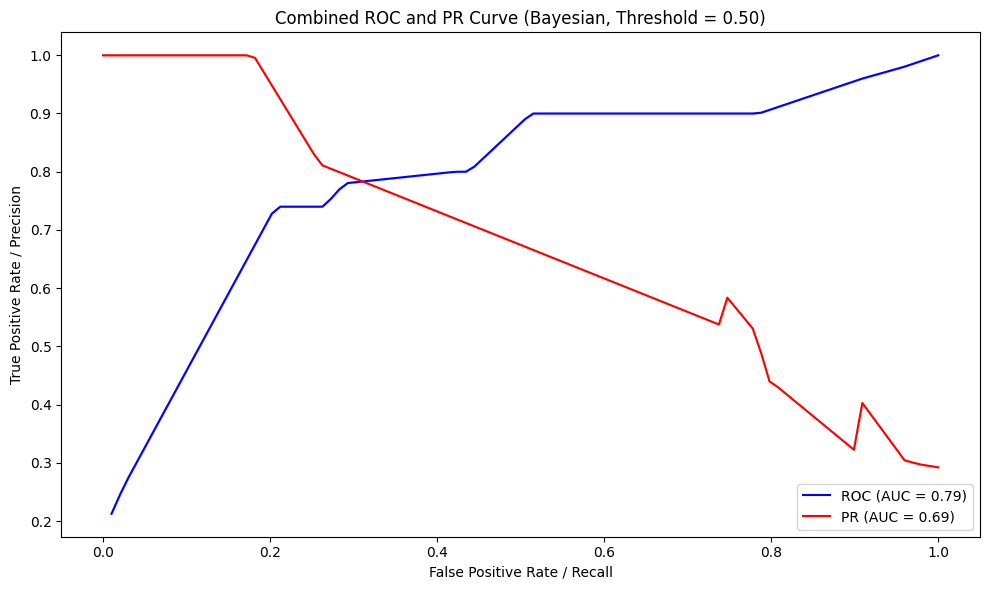

In [ ]:

target="longcovid_six"
X_train, X_test, y_train, y_test = train_test_split(longcovid1, longcovid1[target], test_size=0.35, random_state=42, stratify=longcovid1[target])
threshold = 0.5

all_fpr, all_tpr, all_precision, all_recall = [], [], [], []
fig, ax = plt.subplots(1, figsize=(10, 6))

estimator = BayesianEstimator(bnmodel1, X_train)
for column in longcovid2.columns:
    cpd = estimator.estimate_cpd(column)
    bnmodel1.add_cpds(cpd)

infer = VariableElimination(bnmodel1)
predictions = [infer.query([target], evidence={k: int(v) for k, v in row.to_dict().items() if k != target}).values[1] for _, row in X_test.iterrows()]
newpred = [1 if pred >= threshold else 0 for pred in predictions]

accuracy = accuracy_score(y_test, newpred)
precision = precision_score(y_test, newpred)
recall = recall_score(y_test, newpred)
f1 = f1_score(y_test, newpred)
tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
specificity = tn / (tn + fp)

fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
all_fpr.append(fpr)
all_tpr.append(tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
pr_auc = auc(recall_curve, precision_curve)
all_precision.append(precision_curve)
all_recall.append(recall_curve)


mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
std_tpr = np.std([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)

mean_precision = np.mean([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)
std_precision = np.std([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)


ax.plot(mean_fpr, mean_tpr, color='b', label=f'ROC (AUC = {roc_auc:.2f})')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2)

ax.plot(mean_fpr, mean_precision, color='r', label=f'PR (AUC = {pr_auc:.2f})')
ax.fill_between(mean_fpr, mean_precision - std_precision, mean_precision + std_precision, color='r', alpha=0.2)

ax.set_xlabel('False Positive Rate / Recall')
ax.set_ylabel('True Positive Rate / Precision')
ax.set_title(f'Combined ROC and PR Curve (Bayesian, Threshold = {threshold:.2f})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# infer = VariableElimination(bnmodel1)
# p = 0.5




# for _, row in X_test.iterrows():
#     evidence_dict = {k: str(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}
#     print("Evidence Dictionary:", evidence_dict)

#     longcovid_query = infer.query(['longcovid_six'], evidence=evidence_dict)
#     print("Query Result:", longcovid_query.values[1])

#     prediction = 1 if longcovid_query.values[1] >= p else 0
#     newpred.append(prediction)


In [ ]:
# # Predictions using the Bayesian network
# infer = VariableElimination(bnmodel1)
# p = 0.5

# # Modified predictions code with string conversion for evidence values
# predictions = [
#     infer.query(['longcovid_six'],
#                 evidence={k: str(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}).values[1]
#     for _, row in X_test.iterrows()
# ]
# newpred = [1 if pred >= p else 0 for pred in predictions]

In [ ]:
# Compute metrics
results = pd.DataFrame(columns=['threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity'])

infer = VariableElimination(bnmodel1)

predictions = [infer.query(['longcovid_six'], evidence={k: int(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}).values[1]for _, row in testing_data.iterrows()]
for i in np.arange(0.4,0.9,0.05):
  p =i
  newpred = [1 if pred >= p else 0 for pred in predictions]
  accuracy = accuracy_score(y_test, newpred)

  precision = precision_score(y_test, newpred)
  recall = recall_score(y_test, newpred)
  f1 = f1_score(y_test, newpred)
  tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
  specificity = tn / (tn + fp)
  print(confusion_matrix(y_test, newpred))


  new_row = pd.DataFrame({
    'threshold':[i],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1': [f1],
    'Specificity': [specificity]})
  results = pd.concat([results, new_row], ignore_index=True)

results

[[85 74]
 [ 1 11]]
[[85 74]
 [ 1 11]]
[[85 74]
 [ 1 11]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]
[[156   3]
 [ 10   2]]


,threshold,Accuracy,Precision,Recall,F1,Specificity
0,0.40,0.561404,0.129412,0.916667,0.226804,0.534591
1,0.45,0.561404,0.129412,0.916667,0.226804,0.534591
2,0.50,0.561404,0.129412,0.916667,0.226804,0.534591
3,0.55,0.923977,0.400000,0.166667,0.235294,0.981132
4,0.60,0.923977,0.400000,0.166667,0.235294,0.981132
5,0.65,0.923977,0.400000,0.166667,0.235294,0.981132
6,0.70,0.923977,0.400000,0.166667,0.235294,0.981132
7,0.75,0.923977,0.400000,0.166667,0.235294,0.981132
8,0.80,0.923977,0.400000,0.166667,0.235294,0.981132
9,0.85,0.923977,0.400000,0.166667,0.235294,0.981132
